In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.rc('figure', figsize=(10, 6))

from matplotlib import rcParams
rcParams['font.family'] = 'New Gulim'
rcParams['font.size'] = 10
rcParams['axes.unicode_minus'] = False

import warnings
warnings.filterwarnings(action='ignore')

import os # 파일 시스템 경로 작업을 위해 (CSV 파일 로드 시 유용)

# 데이터 분할 및 모델 선택 도구
from sklearn.model_selection import train_test_split, GridSearchCV

# 전처리 도구
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# 머신러닝 모델
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# 모델 평가 지표
from sklearn.metrics import classification_report, accuracy_score, \
    confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

In [2]:
import os
# 노트북 파일이 있는 폴더로 이동 (예시)
os.chdir(r'C:\githome\hipython_rep')

# 변경 후 확인
print("변경 후:", os.getcwd())

변경 후: C:\githome\hipython_rep


In [3]:
train_df = pd.read_csv('./머신러닝_분류모델/data1/train.csv', encoding='euc-kr')
test_df = pd.read_csv('./머신러닝_분류모델/data1/test.csv', encoding='euc-kr')

In [4]:
train_df.head()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.170000,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.030000,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.770000,0
3,8,2,37,0.0,195.0,195.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,64007.970000,0
4,10,2,39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117310.979016,0


In [5]:
test_df.head()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,...,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38
0,2,2,32,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,40532.10
1,5,2,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,45486.72
2,6,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,46993.95
3,7,2,24,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,187898.61
4,9,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,73649.73


In [21]:
# 드롭할 열의 인덱스 범위를 설정합니다.
# AX열은 인덱스 49, BE열은 인덱스 56입니다.
start_col_index = 49 # AX열
end_col_index = 56   # BE열

# 인덱스를 사용하여 삭제할 열 이름 리스트를 만듭니다.
# DataFrame의 열 이름을 사용하여 특정 인덱스 범위의 열 이름을 가져옵니다.
columns_to_drop_by_index = tr_x.columns[start_col_index : end_col_index + 1].tolist()

In [22]:
tr_x1 = tr_x.drop(columns=columns_to_drop_by_index)

In [ ]:
tr_x = train_df.drop('TARGET' , axis = 1)
tr_y = train_df['TARGET']

In [23]:
x_train, x_test, y_train, y_test = train_test_split(tr_x1, 
                 tr_y, 
                 test_size= 0.2, 
                 random_state= 11)

In [24]:
scaler1 = StandardScaler()
scaler1.fit(x_train)
x_train_scaled = scaler1.transform(x_train)
x_test_scaled = scaler1.transform(x_test)

#  LogisticRegression

In [25]:
model1 = LogisticRegression(random_state= 11)
model1.fit(x_train_scaled, y_train)
pred1 = model1.predict(x_test_scaled)
accuracy_score(y_test, pred1)

0.9601420678768745

In [26]:
confusion_matrix(y_test, pred1)
print(classification_report(y_test, pred1))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     14605
           1       0.00      0.00      0.00       599

    accuracy                           0.96     15204
   macro avg       0.48      0.50      0.49     15204
weighted avg       0.92      0.96      0.94     15204



# DecisionTreeClassifier

In [11]:
model2 = DecisionTreeClassifier()
model2.fit(x_train_scaled, y_train)
pred2 = model2.predict(x_test_scaled)
accuracy_score(y_test, pred2)

0.9259405419626414

In [12]:
confusion_matrix(y_test, pred2)
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96     14605
           1       0.12      0.14      0.13       599

    accuracy                           0.93     15204
   macro avg       0.54      0.55      0.54     15204
weighted avg       0.93      0.93      0.93     15204



# RandomForestClassifier

In [13]:
model3 = RandomForestClassifier(random_state=0, max_depth=8)
model3.fit(x_train_scaled, y_train)
pred3 = model3.predict(x_test_scaled)
accuracy_score(y_test, pred3)

0.9606024730334123

In [14]:
confusion_matrix(y_test, pred3)
print(classification_report(y_test, pred3))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     14605
           1       0.00      0.00      0.00       599

    accuracy                           0.96     15204
   macro avg       0.48      0.50      0.49     15204
weighted avg       0.92      0.96      0.94     15204



# XGBoost

In [15]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)  # Series → 1D array
y_test_encoded = le.transform(y_test)

In [30]:
xgb_model = XGBClassifier(
    n_estimators=1000, # n_estimators를 충분히 높게 설정하고 early stopping을 고려
    learning_rate=0.05, # learning_rate를 조금 낮춰서 더 정교하게 학습
    max_depth=5,        # 깊이를 약간 늘려 복잡한 패턴 학습 유도
    min_child_weight=1, # 기본값 1 유지 또는 더 낮게 (불균형 데이터에서는 1이 적절)
    gamma=0.1,          # 작은 gamma 값으로 더 많은 분할 유도
    subsample=0.7,
    colsample_bytree=0.7,

    objective='binary:logistic', # 이진 분류 기본 objective
    eval_metric='aucpr', # 훈련 중 평가 지표. Recall 대신 AUCPR도 불균형 데이터에 좋음.
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(x_train_scaled, y_train_encoded)
xgb_predictions = xgb_model.predict(x_test_scaled)
accuracy_score(y_test_encoded,xgb_predictions)

0.9601420678768745

In [31]:
confusion_matrix(y_test_encoded, xgb_predictions)
print(classification_report(y_test_encoded, xgb_predictions))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     14605
           1       0.27      0.01      0.01       599

    accuracy                           0.96     15204
   macro avg       0.61      0.50      0.50     15204
weighted avg       0.93      0.96      0.94     15204



<Axes: >

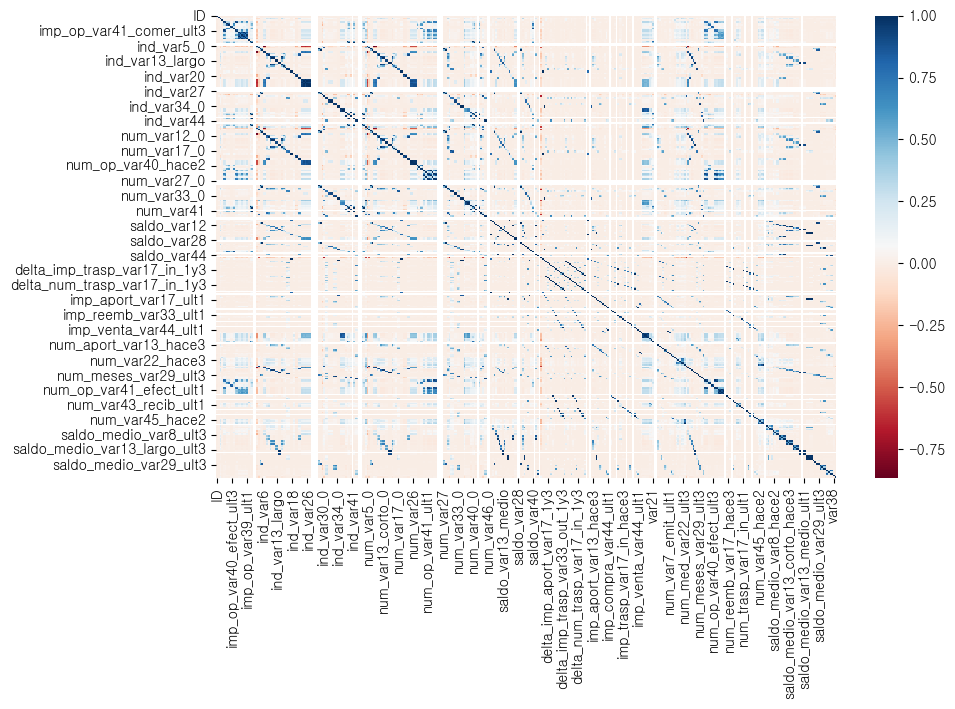

In [20]:
corr=train_df.corr()
sns.heatmap(corr, cmap='RdBu')